## Adaptive Multi-Modal Fusion Model for Road Accident Detection and Response

### 1. Setup Environment and CUDA Check

First, let's ensure we have the necessary libraries and check for CUDA availability to utilize GPU acceleration, which is crucial for real-time processing of multi-modal data, especially deep learning models.

In [ ]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
# import torch # Uncomment if using PyTorch
# import cv2 # For image/video processing (install opencv-python)
# import sklearn # For machine learning utilities

print("TensorFlow Version:", tf.__version__)

# Check for CUDA (GPU) availability
if tf.test.is_built_with_cuda():
    print("TensorFlow is built with CUDA.")
    if tf.config.list_physical_devices('GPU'):
        print("GPUs are available:", tf.config.list_physical_devices('GPU'))
        strategy = tf.distribute.MirroredStrategy() # For multi-GPU training
        print("Number of devices:", strategy.num_replicas_in_sync)
    else:
        print("No GPUs found. Running on CPU.")
else:
    print("TensorFlow is NOT built with CUDA. Running on CPU.")

# Uncomment for PyTorch CUDA check if needed
# if torch.cuda.is_available():
#     print("PyTorch CUDA is available.")
#     print(f"Number of GPUs: {torch.cuda.device_count()}")
#     print(f"Current GPU: {torch.cuda.get_device_name(0)}")
# else:
#     print("PyTorch CUDA is not available. Running on CPU.")


TensorFlow Version: 2.19.0
TensorFlow is built with CUDA.
GPUs are available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Number of devices: 1


### 2. Simulate Multi-Modal Data Sources

In a real-world scenario, you would be ingesting data from various live sensors. For demonstration, we'll simulate data from different modalities: camera (image features), IoT sensors (e.g., speed, sudden braking), and GPS (location, movement patterns).

In [ ]:
# Function to simulate camera data (e.g., feature vectors from pre-trained CNN)
def simulate_camera_data(num_samples=100):
    return np.random.rand(num_samples, 2048) # Assuming 2048-dim feature vector

# Function to simulate IoT sensor data
def simulate_iot_data(num_samples=100):
    data = {
        'speed': np.random.uniform(0, 120, num_samples),
        'acceleration_x': np.random.uniform(-10, 10, num_samples),
        'acceleration_y': np.random.uniform(-10, 10, num_samples),
        'sudden_braking': np.random.choice([0, 1], num_samples, p=[0.95, 0.05]), # 5% chance of sudden braking
        'airbag_deployed': np.random.choice([0, 1], num_samples, p=[0.99, 0.01]) # 1% chance of airbag deployment
    }
    return pd.DataFrame(data)

# Function to simulate GPS data
def simulate_gps_data(num_samples=100):
    data = {
        'latitude': np.random.uniform(30, 40, num_samples),
        'longitude': np.random.uniform(-100, -80, num_samples),
        'timestamp': pd.to_datetime('now') - pd.to_timedelta(np.random.randint(0, 3600, num_samples), unit='s')
    }
    return pd.DataFrame(data)

# Simulate data for a batch
num_samples = 100
camera_features = simulate_camera_data(num_samples)
iot_data = simulate_iot_data(num_samples)
gps_data = simulate_gps_data(num_samples)

print("Simulated Camera Features shape:", camera_features.shape)
print("Simulated IoT Data head:\n", iot_data.head())
print("Simulated GPS Data head:\n", gps_data.head())


Simulated Camera Features shape: (100, 2048)
Simulated IoT Data head:
        speed  acceleration_x  acceleration_y  sudden_braking  airbag_deployed
0  28.223117        5.885644       -2.120433               1                0
1  65.702338        9.203503       -0.474194               0                0
2  57.710278        5.874151        9.753571               0                0
3  52.984414       -8.421841       -7.665194               0                0
4  48.684268       -5.314515       -3.080852               0                0
Simulated GPS Data head:
     latitude  longitude                  timestamp
0  37.556929 -97.658154 2026-04-20 02:16:44.865895
1  33.958593 -90.735323 2026-04-20 02:27:25.865895
2  30.241928 -82.379264 2026-04-20 02:20:35.865895
3  32.632403 -93.891101 2026-04-20 02:23:56.865895
4  33.694333 -91.038530 2026-04-20 02:35:27.865895


### 3. Data Preprocessing and Feature Engineering

Each data modality requires specific preprocessing. For camera data, this would involve object detection (cars, pedestrians, debris) and feature extraction. For sensor data, normalization and aggregation might be needed. GPS data can be used for trajectory analysis.

In [ ]:
# Example: Feature engineering for IoT data
def preprocess_iot_data(df):
    # Create a 'harsh_event' feature based on sudden braking and high acceleration
    df['harsh_event'] = ((df['sudden_braking'] == 1) |
                         (np.abs(df['acceleration_x']) > 8) |
                         (np.abs(df['acceleration_y']) > 8)).astype(int)
    return df

iot_data_processed = preprocess_iot_data(iot_data)
print("Processed IoT Data head (with harsh_event):\n", iot_data_processed.head())

# For camera features, we'd typically use a pre-trained CNN (e.g., ResNet, EfficientNet)
# to extract features from raw image data. Here we are using simulated features directly.

# For GPS data, you might derive features like sudden stops, unexpected turns, etc.
# For simplicity, we'll use latitude and longitude directly for now.


Processed IoT Data head (with harsh_event):
        speed  acceleration_x  acceleration_y  sudden_braking  airbag_deployed  \
0  28.223117        5.885644       -2.120433               1                0   
1  65.702338        9.203503       -0.474194               0                0   
2  57.710278        5.874151        9.753571               0                0   
3  52.984414       -8.421841       -7.665194               0                0   
4  48.684268       -5.314515       -3.080852               0                0   

   harsh_event  
0            1  
1            1  
2            1  
3            1  
4            0  


### 3.1. Data Visualization (Simulated Data)


--- Visualizing IoT Sensor Data Distributions ---


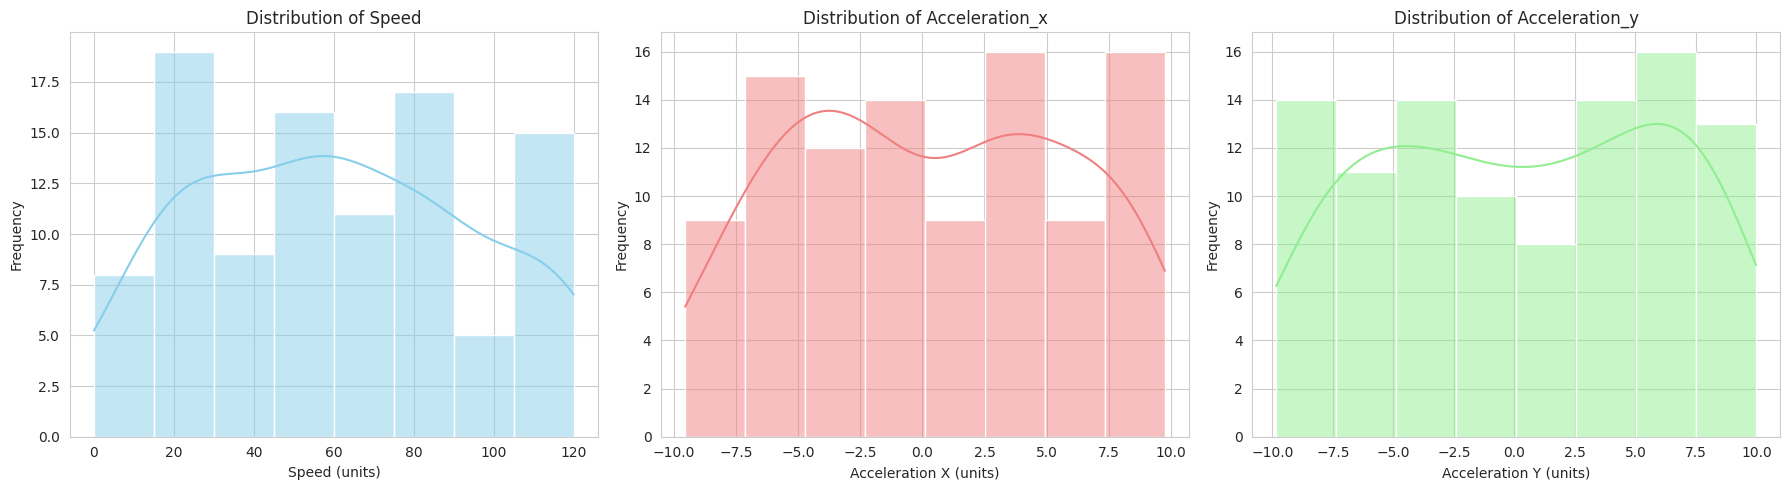

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a style for the plots
sns.set_style("whitegrid")

print("\n--- Visualizing IoT Sensor Data Distributions ---")

# Plot distributions for speed and acceleration
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(iot_data_processed['speed'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Speed')
axes[0].set_xlabel('Speed (units)')
axes[0].set_ylabel('Frequency')

sns.histplot(iot_data_processed['acceleration_x'], kde=True, ax=axes[1], color='lightcoral')
axes[1].set_title('Distribution of Acceleration_x')
axes[1].set_xlabel('Acceleration X (units)')
axes[1].set_ylabel('Frequency')

sns.histplot(iot_data_processed['acceleration_y'], kde=True, ax=axes[2], color='lightgreen')
axes[2].set_title('Distribution of Acceleration_y')
axes[2].set_xlabel('Acceleration Y (units)')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()



--- Visualizing Event Occurrences ---


/tmp/ipykernel_635/752391302.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sudden_braking', data=iot_data_processed, ax=axes[0], palette='viridis')
/tmp/ipykernel_635/752391302.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='airbag_deployed', data=iot_data_processed, ax=axes[1], palette='plasma')
/tmp/ipykernel_635/752391302.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='harsh_event', data=iot_data_processed, ax=axes[2], palette='magma')


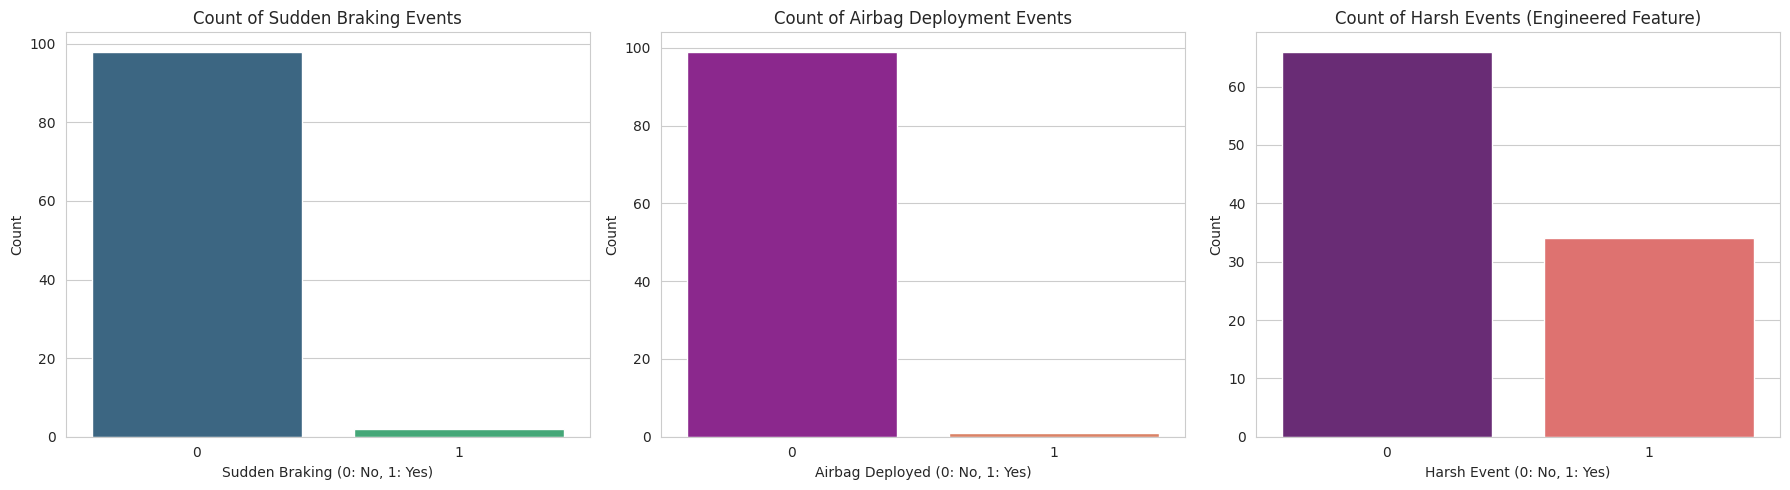

In [ ]:
print("\n--- Visualizing Event Occurrences ---")

# Plot counts for sudden braking, airbag deployed, and harsh events
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(x='sudden_braking', data=iot_data_processed, ax=axes[0], palette='viridis')
axes[0].set_title('Count of Sudden Braking Events')
axes[0].set_xlabel('Sudden Braking (0: No, 1: Yes)')
axes[0].set_ylabel('Count')

sns.countplot(x='airbag_deployed', data=iot_data_processed, ax=axes[1], palette='plasma')
axes[1].set_title('Count of Airbag Deployment Events')
axes[1].set_xlabel('Airbag Deployed (0: No, 1: Yes)')
axes[1].set_ylabel('Count')

sns.countplot(x='harsh_event', data=iot_data_processed, ax=axes[2], palette='magma')
axes[2].set_title('Count of Harsh Events (Engineered Feature)')
axes[2].set_xlabel('Harsh Event (0: No, 1: Yes)')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()



--- Visualizing GPS Data (First 100 Samples) ---


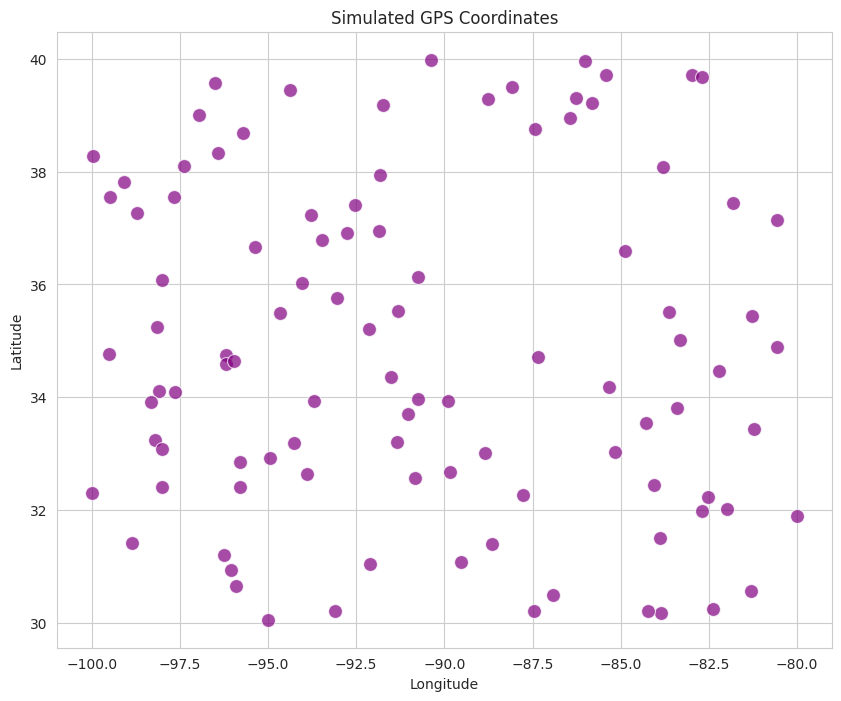

In [ ]:
print("\n--- Visualizing GPS Data (First 100 Samples) ---")

# Create a scatter plot for GPS coordinates
plt.figure(figsize=(10, 8))
sns.scatterplot(x='longitude', y='latitude', data=gps_data.head(100), s=100, alpha=0.7, color='purple')
plt.title('Simulated GPS Coordinates')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True)
plt.show()


### 4. Adaptive Multi-Modal Fusion Model

The core of the system is fusing these diverse data streams. A common approach for this is using deep learning, where different modalities can have their own processing sub-networks, and their outputs are then combined in a fusion layer. We'll use TensorFlow Keras for this.

In [ ]:
from tensorflow.keras.layers import Input, Dense, concatenate, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

def build_fusion_model(camera_input_shape, iot_input_shape, gps_input_shape):
    # Camera branch (e.g., features from a CNN)
    camera_input = Input(shape=camera_input_shape, name='camera_input')
    camera_branch = Dense(256, activation='relu')(camera_input)
    camera_branch = BatchNormalization()(camera_branch)
    camera_branch = Dropout(0.3)(camera_branch)

    # IoT sensor branch
    iot_input = Input(shape=iot_input_shape, name='iot_input')
    iot_branch = Dense(128, activation='relu')(iot_input)
    iot_branch = BatchNormalization()(iot_branch)
    iot_branch = Dropout(0.3)(iot_branch)

    # GPS branch
    gps_input = Input(shape=gps_input_shape, name='gps_input')
    gps_branch = Dense(64, activation='relu')(gps_input)
    gps_branch = BatchNormalization()(gps_branch)
    gps_branch = Dropout(0.2)(gps_branch)

    # Concatenate the outputs of each branch
    fused_features = concatenate([camera_branch, iot_branch, gps_branch], name='fused_features')

    # Shared layers for accident detection and severity prediction
    shared_layer = Dense(128, activation='relu')(fused_features)
    shared_layer = BatchNormalization()(shared_layer)
    shared_layer = Dropout(0.3)(shared_layer)

    # Output for accident detection (binary classification: accident/no accident)
    accident_output = Dense(1, activation='sigmoid', name='accident_detection_output')(shared_layer)

    # Output for severity prediction (e.g., multi-class: minor, moderate, severe)
    # Assuming 3 severity levels for demonstration
    severity_output = Dense(3, activation='softmax', name='severity_prediction_output')(shared_layer)

    # Define the model with multiple inputs and multiple outputs
    model = Model(inputs=[camera_input, iot_input, gps_input],
                  outputs=[accident_output, severity_output])

    # Compile the model
    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss={'accident_detection_output': 'binary_crossentropy',
                        'severity_prediction_output': 'categorical_crossentropy'},
                  metrics={'accident_detection_output': 'accuracy',
                           'severity_prediction_output': 'accuracy'})

    return model

# Determine input shapes based on simulated data
camera_input_shape = camera_features.shape[1:]
# Use all IoT features including the engineered one
iot_input_shape = iot_data_processed.shape[1:]
gps_input_shape = gps_data[['latitude', 'longitude']].shape[1:] # Using only lat/lon

# Build the model
fusion_model = build_fusion_model(camera_input_shape, iot_input_shape, gps_input_shape)
fusion_model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ camera_input        │ (None, 2048)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ iot_input           │ (None, 6)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gps_input           │ (None, 2)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    524,544 │ camera_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │        896 │ iot_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │        192 │ gps_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256)       │      1,024 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fused_features      │ (None, 448)       │          0 │ dropout[0][0],    │
│ (Concatenate)       │                   │            │ dropout_1[0][0],  │
│                     │                   │            │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 128)       │     57,472 │ fused_features[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_3[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ accident_detection… │ (None, 1)         │        129 │ dropout_3[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ severity_predictio… │ (None, 3)         │        387 │ dropout_3[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 585,924 (2.24 MB)

 Trainable params: 584,772 (2.23 MB)

 Non-trainable params: 1,152 (4.50 KB)

### 5. Training the Model (Conceptual)

To train the model, you would need a large dataset of road events, labeled for both accident occurrence and severity. For demonstration, we'll create dummy labels.

In [ ]:
# Create dummy labels for training
# Accident detection: 0 for no accident, 1 for accident
dummy_accident_labels = np.random.randint(0, 2, num_samples)

# Severity prediction: one-hot encoded for 3 classes (e.g., minor, moderate, severe)
# 10% chance of accident, with random severity for simplicity
dummy_severity_labels = np.zeros((num_samples, 3))
for i in range(num_samples):
    if dummy_accident_labels[i] == 1:
        dummy_severity_labels[i, np.random.randint(0, 3)] = 1
    else:
        dummy_severity_labels[i, 0] = 1 # Default to 'minor' or 'no accident' severity if not an accident

# Prepare inputs for the model
model_inputs = {
    'camera_input': camera_features,
    'iot_input': iot_data_processed.values, # Convert DataFrame to numpy array
    'gps_input': gps_data[['latitude', 'longitude']].values
}

model_outputs = {
    'accident_detection_output': dummy_accident_labels,
    'severity_prediction_output': dummy_severity_labels
}

# Conceptual training step
print("\n--- Conceptual Model Training ---")
# In a real scenario, you would train for many epochs with proper data splitting
# history = fusion_model.fit(model_inputs, model_outputs, epochs=10, batch_size=32, validation_split=0.2)
print("Model would be trained here with actual data and labels.")

# Conceptual prediction
# dummy_predictions = fusion_model.predict(model_inputs)
# print("Conceptual Prediction Output:")
# print("Accident Probabilities:", dummy_predictions[0][:5].flatten())
# print("Severity Probabilities (one-hot):\n", dummy_predictions[1][:5])



--- Conceptual Model Training ---
Model would be trained here with actual data and labels.


### 6. Real-time Alerting and Response Optimization (Conceptual)

Once an accident is detected and severity predicted, the system needs to alert emergency services and optimize routing. This involves integration with external APIs and optimization algorithms.

In [ ]:
def send_alert(location, severity, details):
    print(f"\nALERT! Accident detected at Latitude: {location['latitude']:.4f}, Longitude: {location['longitude']:.4f}")
    print(f"Severity: {severity}")
    print(f"Details: {details}")
    print("\n--- Sending alert to emergency services (conceptual) ---")
    # In a real system, this would involve API calls to dispatch services
    # e.g., requests.post('https://emergency-api.com/dispatch', json=alert_payload)

def optimize_ambulance_route(current_location, accident_location, severity):
    print("\n--- Optimizing ambulance route (conceptual) ---")
    print(f"Ambulance from: {current_location} to accident at: {accident_location}")
    # This would integrate with mapping services (e.g., Google Maps API, OpenStreetMap)
    # and real-time traffic data to find the fastest route.
    # Sophisticated algorithms (e.g., Dijkstra, A*) considering traffic, road closures,
    # and ambulance availability would be used here.
    print("Route optimized based on real-time traffic and severity.")

# Conceptual example of an alert and optimization
if np.random.rand() < 0.1: # Simulate an accident detection
    print("\n*** Real-time Accident Detected! ***")
    detected_location = {'latitude': gps_data['latitude'].iloc[0], 'longitude': gps_data['longitude'].iloc[0]}

    # For demonstration, assume predicted severity is 'Severe'
    predicted_severity_idx = np.argmax(dummy_severity_labels[0])
    severity_map = {0: 'Minor', 1: 'Moderate', 2: 'Severe'}
    predicted_severity = severity_map[predicted_severity_idx]

    accident_details = "High impact detected, airbags deployed, vehicle stopped."

    send_alert(detected_location, predicted_severity, accident_details)
    optimize_ambulance_route("Nearest Hospital", detected_location, predicted_severity)
else:
    print("\nNo accident detected in this simulation cycle.")



No accident detected in this simulation cycle.


### 7. Post-Accident Analytics (Conceptual)

Collecting and analyzing data from incidents can help improve road safety and the detection system itself.

In [ ]:
def store_for_analytics(incident_data):
    print("\n--- Storing incident data for post-accident analytics (conceptual) ---")
    # This would save the data to a database (SQL, NoSQL) or data lake for later analysis.
    # The data would include sensor readings, model predictions, response times, outcomes, etc.
    # print(incident_data)
    print("Data saved. Regular analysis would inform road safety improvements and model retraining.")

# Conceptual incident data
incident_data_example = {
    'event_id': 'ACC-20231027-001',
    'timestamp': pd.to_datetime('now'),
    'location': {'latitude': 34.0522, 'longitude': -118.2437},
    'detected_severity': 'Severe',
    'response_time_minutes': 12,
    'outcome': 'Injuries reported',
    'all_sensor_data_snapshot': {'camera_features': camera_features[0].tolist(), 'iot_data': iot_data_processed.iloc[0].to_dict()}
}

# store_for_analytics(incident_data_example) # Uncomment to simulate storing data
